### Imports

In [2]:
import math
import matplotlib.pyplot as plt
import numpy as np
import random

%matplotlib inline

### Logistic Regression Overview

#### Loss function (Binary Cross-entropy)
- $L(p, t) = (-1)*(t * log(p) + (1 - t) * log(1 - p))$
- $z = mx + b$
- $p = f(x) = \frac{1}{1 + e^-z} = σ(x)$
  - $p$ is predicted, $t$ is the target.

#### Cost function
- $J = \frac{1}{N} \sum_{i=1}^{N} L(p_i, t_i)$

### Gradient
- $\frac{d}{dx} lnu = \frac{1}{u} ⋅ \frac{du}{dx}$
- $\frac{∂L}{∂m} = \frac{∂L}{∂p} \frac{∂p}{∂z} \frac{∂z}{∂m}$
  - $\frac{dL}{dp} = (-1)⋅(\frac{t}{p} - \frac{1}{1 - p} + \frac{t}{1 - p}) = (-1) ⋅ \frac{t - p}{p (1 - p)} = \frac{p - t}{p(1 - p)}$
  - $\frac{dp}{dz} = p(1 - p)$
  - $\frac{dz}{dm} = x$
  - ⇒ $\frac{dL}{dm} = \frac{p - t}{p(1-p)} ⋅ p(1-p) ⋅ x = (p - t) ⋅ x$
- $\frac{∂L}{∂b} = \frac{∂L}{∂p} \frac{∂p}{∂z} \frac{∂z}{∂b}$
  - $\frac{dL}{dp} = \frac{(p - t)}{p(1 - p)}$
  - $\frac{dp}{dz} = p * (1 - p)$
  - $\frac{dz}{db} = 1$
  - ⇒ $\frac{dL}{db} = \frac{(p - t)}{p(1-p)} ⋅ p(1-p) ⋅ 1 = (p - t)$

### Dataset

In [6]:
# Income $0 to $150,000 (In $10K units)
xs = []
# 0=false, 1=true
ys = []

In [7]:
# Unhappy data
for i in range(100):
  xs.append(random.gauss(3.5, 1.0))
  ys.append(0)

# Happy data
for i in range(100):
  xs.append(random.gauss(9.5, 1.0))
  ys.append(1)

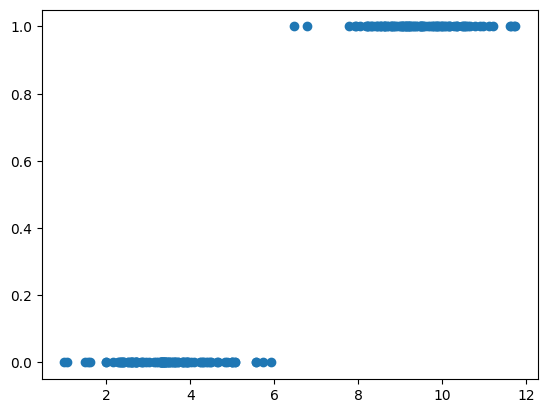

In [8]:
plt.plot(xs, ys, 'o')

### Train

In [9]:
def sigmoid(z):
  return 1.0 / (1.0 + math.exp(-z))

In [12]:
def calc_loss(y_target, y_pred):
  N = len(y_target)

  total = 0.0
  for i in range(N):
    if y_target[i] == 1:
      total += (y_target[i] * math.log(y_pred[i]))
    else:
      total += (1 - y_target[i]) * math.log(1 - y_pred[i])

  return (-1.0 / N) * (total)

In [14]:
def train(w, b, xs, y_target, lr=0.02, epochs=7500):
  history = []
  N = len(xs)

  for ep in range(epochs):    
    y_pred = [sigmoid(w*xs[i] + b) for i in range(N)]

    dw = (-1.0 / N)*sum([(y_target[i] - y_pred[i])*xs[i] for i in range(N)])
    db = (-1.0 / N)*sum([(y_target[i] - y_pred[i]) for i in range(N)])

    w -= lr*dw
    b -= lr*db
    
    # print(ep, w, b)
    loss = calc_loss(y_target, y_pred)
    history.append(loss)

  return w, b, history

### Evaluate

In [15]:
w = random.random()
b = 0.0

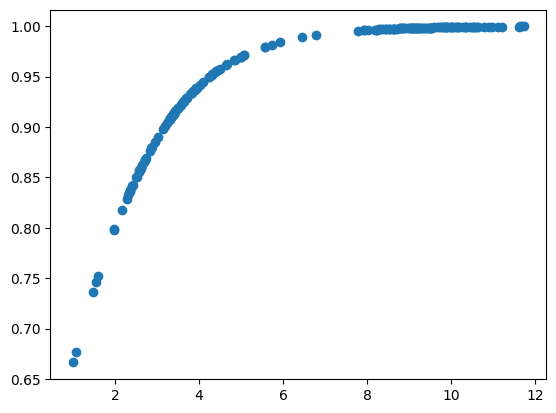

In [16]:
y_pred = [sigmoid(w*x + b) for x in xs]

plt.plot(xs, y_pred, 'o')

In [17]:
w, b, history = train(w, b, xs, ys, epochs=10000)

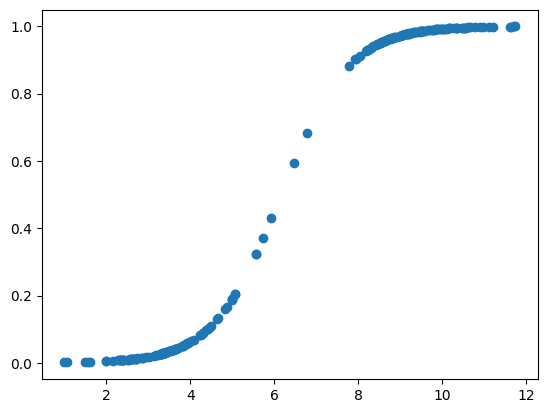

In [18]:
y_pred = [sigmoid(w*x + b) for x in xs]

plt.plot(xs, y_pred, 'o')